In [1]:
print("name-AtulSingh UIN-221A016")
!pip install 'gymnasium[atari]'
import gymnasium as gym
import ale_py # Explicitly import ale_py to ensure ALE environments are registered
gym.pprint_registry()
env = gym.make("ALE/Pong-v5")

name-AtulSingh UIN-221A016
===== classic_control =====
Acrobot-v1                  CartPole-v0                 CartPole-v1
MountainCar-v0              MountainCarContinuous-v0    Pendulum-v1
===== phys2d =====
phys2d/CartPole-v0          phys2d/CartPole-v1          phys2d/Pendulum-v0
===== box2d =====
BipedalWalker-v3            BipedalWalkerHardcore-v3    CarRacing-v3
LunarLander-v3              LunarLanderContinuous-v3
===== toy_text =====
Blackjack-v1                CliffWalking-v1             CliffWalkingSlippery-v1
FrozenLake-v1               FrozenLake8x8-v1            Taxi-v3
===== tabular =====
tabular/Blackjack-v0        tabular/CliffWalking-v0
===== None =====
Ant-v2                      Ant-v3                      GymV21Environment-v0
GymV26Environment-v0        HalfCheetah-v2              HalfCheetah-v3
Hopper-v2                   Hopper-v3                   Humanoid-v2
Humanoid-v3                 HumanoidStandup-v2          InvertedDoublePendulum-v2
InvertedPendulum-v2    

In [2]:
print("name-AtulSingh UIN-221A016")
import gymnasium as gym
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque

name-AtulSingh UIN-221A016


In [3]:
print("name-AtulSingh UIN-221A016")
class DQN(nn.Module):
    def __init__(self, input_shape, action_dim):
        super(DQN, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(3136, 512),
            nn.ReLU(),
            nn.Linear(512, action_dim)
        )
    def forward (self,x):
      return self.net(x/255.0)

name-AtulSingh UIN-221A016


In [4]:
print("name-AtulSingh UIN-221A016")
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
    def push(self,state, action,reward,next_state ,done):
      self.buffer.append((state,action,reward,next_state,done))
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
             np.array(states),
             np.array(actions),
             np.array(rewards),
             np.array(next_states),
             np.array(dones)
        )
    def __len__(self):
      return len(self.buffer)

name-AtulSingh UIN-221A016


In [5]:
print("name-AtulSingh UIN-221A016")
BATCH_SIZE =32
GAMMA=0.99
LR = 1e-4
BUFFER_SIZE = 100000
EPSILON_START = 1.0
EPSILON_END = 0.1
EPSILON_DECAY = 100000
TARGET_UPDATE = 1000

name-AtulSingh UIN-221A016


In [6]:
print("name-AtulSingh UIN-221A016")
import ale_py
env = gym.make("ALE/Pong-v5",render_mode=None)
n_action = env.action_space.n
input_shape = (4,84,84)

name-AtulSingh UIN-221A016


In [7]:
print("name-AtulSingh UIN-221A016")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
policy_net = DQN(input_shape, n_action).to(device)
target_net = DQN(input_shape, n_action).to(device)
target_net.load_state_dict(policy_net.state_dict())
optimizer = optim.Adam(policy_net.parameters(), lr=LR)
replay_buffer = ReplayBuffer(BUFFER_SIZE)

name-AtulSingh UIN-221A016


In [8]:
print("name-AtulSingh UIN-221A016")
def epsilon_by_frame(frame_idx):
    return EPSILON_END + (EPSILON_START - EPSILON_END) * \
           np.exp(-1. * frame_idx / EPSILON_DECAY)

def select_action(state, epsilon):
    if random.random() < epsilon:
        return random.randrange(n_action)
    else:
        state = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        q_values = policy_net(state)
        return q_values.max(1)[1].item()

name-AtulSingh UIN-221A016


In [9]:
print("name-AtulSingh UIN-221A016")
def train_step():
    if len(replay_buffer) < BATCH_SIZE:
        return
    states, actions, rewards, next_states, dones = replay_buffer.sample(BATCH_SIZE)
    states = torch.tensor(states, dtype=torch.float32).to(device)
    next_states = torch.tensor(next_states, dtype=torch.float32).to(device)
    actions = torch.tensor(actions).unsqueeze(1).to(device)
    rewards = torch.tensor(rewards).to(device)
    dones = torch.tensor(dones).to(device)
    q_values = policy_net(states).gather(1, actions).squeeze(1)
    next_q_values = target_net(next_states).max(1)[0]
    expected_q = rewards + GAMMA * next_q_values * (1 - dones)
    loss = nn.MSELoss()(q_values, expected_q.detach())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

name-AtulSingh UIN-221A016


In [10]:
print("name-AtulSingh UIN-221A016")
env = gym.make("ALE/Pong-v5",render_mode="rgb_array")

name-AtulSingh UIN-221A016


In [11]:
print("name-AtulSingh UIN-221A016")
env.reset()

name-AtulSingh UIN-221A016


(array([[[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [109, 118,  43],
         [109, 118,  43],
         [109, 118,  43]],
 
        [[109, 118,  43],
         [109, 118,  43],
         [109, 118,  43],
         ...,
         [109, 118,  43],
         [109, 118,  43],
         [109, 118,  43]],
 
        [[109, 118,  43],
         [109, 118,  43],
         [109, 118,  43],
         ...,
         [109, 118,  43],
         [109, 118,  43],
         [109, 118,  43]],
 
        ...,
 
        [[ 53,  95,  24],
         [ 53,  95,  24],
         [ 53,  95,  24],
         ...,
         [ 53,  95,  24],
         [ 53,  95,  24],
         [ 53,  95,  24]],
 
        [[ 53,  95,  24],
         [ 53,  95,  24],
         [ 53,  95,  24],
         ...,
         [ 53,  95,  24],
         [ 53,  95,  24],
         [ 53,  95,  24]],
 
        [[ 53,  95,  24],
         [ 53,  95,  24],
         [ 53,  95,  24],
         ...,
         [ 53,  95,  24],
  

name-AtulSingh UIN-221A016


array([[[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [109, 118,  43],
        [109, 118,  43],
        [109, 118,  43]],

       [[109, 118,  43],
        [109, 118,  43],
        [109, 118,  43],
        ...,
        [109, 118,  43],
        [109, 118,  43],
        [109, 118,  43]],

       [[109, 118,  43],
        [109, 118,  43],
        [109, 118,  43],
        ...,
        [109, 118,  43],
        [109, 118,  43],
        [109, 118,  43]],

       ...,

       [[ 53,  95,  24],
        [ 53,  95,  24],
        [ 53,  95,  24],
        ...,
        [ 53,  95,  24],
        [ 53,  95,  24],
        [ 53,  95,  24]],

       [[ 53,  95,  24],
        [ 53,  95,  24],
        [ 53,  95,  24],
        ...,
        [ 53,  95,  24],
        [ 53,  95,  24],
        [ 53,  95,  24]],

       [[ 53,  95,  24],
        [ 53,  95,  24],
        [ 53,  95,  24],
        ...,
        [ 53,  95,  24],
        [ 53,  95,  24],
        [ 53,  95,  24]]], dtype=uint8)
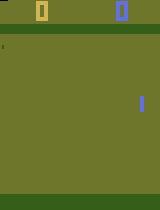

In [12]:
print("name-AtulSingh UIN-221A016")
env.render()

In [13]:
print("name-AtulSingh UIN-221A016")
num_frames = 200000

# Initialize the environment and get the initial observation and info.
initial_observation, initial_info = env.reset()

# NOTE: Proper preprocessing (grayscale, resize, frame stack) needed here
# This line uses a placeholder state, as indicated in the original code comments.
state = np.zeros(input_shape, dtype=np.float32) # placeholder for initial state

for frame_idx in range(1, num_frames + 1):
    epsilon = epsilon_by_frame(frame_idx)

    action = select_action(state, epsilon)

    # Execute the action in the environment.
    observation, reward, terminated, truncated, info = env.step(action)

    # Determine if the episode is done.
    done = terminated or truncated

    # NOTE: Proper preprocessing for next_state also needed here.
    next_state = np.zeros(input_shape, dtype=np.float32) # placeholder for next state

    replay_buffer.push(state, action, reward, next_state, done)
    state = next_state
    train_step()
    if frame_idx % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())
    if done:
        state, _ = env.reset()
        state = np.zeros(input_shape) # placeholder for initial state

name-AtulSingh UIN-221A016


RuntimeError: Subtraction, the `-` operator, with a bool tensor is not supported. If you are trying to invert a mask, use the `~` or `logical_not()` operator instead.

In [ ]:
print("name-AtulSingh UIN-221A016")
def train_step():
    if len(replay_buffer) < BATCH_SIZE:
        return
    states, actions, rewards, next_states, dones = replay_buffer.sample(BATCH_SIZE)
    states = torch.tensor(states, dtype=torch.float32).to(device)
    next_states = torch.tensor(next_states, dtype=torch.float32).to(device)
    actions = torch.tensor(actions).unsqueeze(1).to(device)
    rewards = torch.tensor(rewards, dtype=torch.float32).to(device) # Explicitly cast rewards to float32
    dones = torch.tensor(dones, dtype=torch.float32).to(device) # Convert to float
    q_values = policy_net(states).gather(1, actions).squeeze(1)
    next_q_values = target_net(next_states).max(1)[0]
    expected_q = rewards + GAMMA * next_q_values * (1 - dones)
    loss = nn.MSELoss()(q_values, expected_q.detach())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()